Processing 2020...
  Using cached results for 2020
Processing 2021...
  Using cached results for 2021
Processing 2022...
  Using cached results for 2022
Processing 2023...
  Using cached results for 2023
Processing 2024...
  Using cached results for 2024
Processing 2025...
  Using cached results for 2025
Computing averages...

Filtering pixel-years by CI width...
  2020: 209 pixels (all phases)  |  start: 213  middle: 332  end: 218
  2021: 354 pixels (all phases)  |  start: 366  middle: 582  end: 363
  2022: 314 pixels (all phases)  |  start: 384  middle: 969  end: 397
  2023: 224 pixels (all phases)  |  start: 308  middle: 1089  end: 348
  2024: 209 pixels (all phases)  |  start: 376  middle: 586  end: 285
  2025: 120 pixels (all phases)  |  start: 185  middle: 480  end: 179

Total pixel-years with all CI widths < 15 days: 1430
  By phase — start: 1832  middle: 4038  end: 1790

Building labeled EVI table...
  2020: 209 qualifying pixels
  2021: 354 qualifying pixels
  2022: 314 qualif

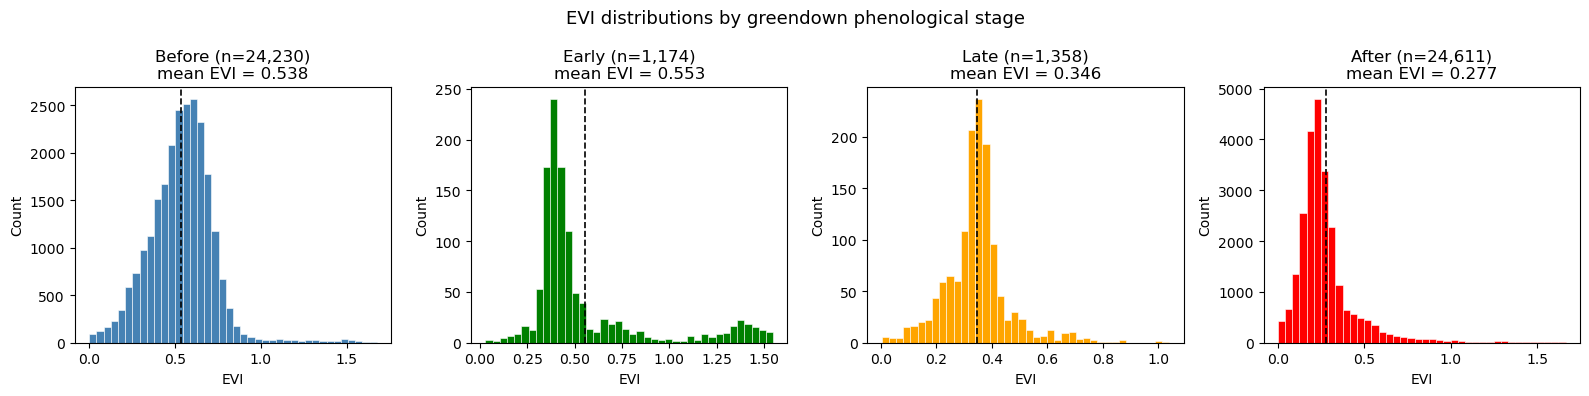

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [3]:
import datetime
import os
import matplotlib.pyplot as plt
import ee
import geemap

from identify_locations import identify_forests, identify_route_buffer
from read_and_process_hls import compute_hls_evi
from fit_greendown_curves import compute_transition_dates, compute_average_transition_dates
from filter_ci_widths import count_narrow_ci_pixel_years
from label_evi import build_labeled_evi_table

ee.Initialize(project='turnkey-lacing-391919')

OUTPUT_DIR = './greendown_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ma_forest    = identify_forests()
route_buffer = identify_route_buffer()

start_year    = 2020
previous_year = 2025

# ----------------------------
# Fit logistic curves for each year
# ----------------------------
all_year_paths = []
for y in range(start_year, previous_year + 1):
    print(f'Processing {y}...')
    hls   = compute_hls_evi(route_buffer, ma_forest, y)
    paths = compute_transition_dates(hls, route_buffer, ma_forest, y, output_dir=OUTPUT_DIR)
    all_year_paths.append(paths)

prev_year_paths = all_year_paths[-1]   # most recent year

# ----------------------------
# Average transition dates across all years
# ----------------------------
print('Computing averages...')
avg_paths = compute_average_transition_dates(all_year_paths, output_dir=OUTPUT_DIR)

# ----------------------------
# Filter: pixels with CI width < 15 days for all transitions
# ----------------------------
print('\nFiltering pixel-years by CI width...')
years = list(range(start_year, previous_year + 1))
count_narrow_ci_pixel_years(OUTPUT_DIR, years)

# ----------------------------
# Label EVI observations and plot histograms
# ----------------------------
print('\nBuilding labeled EVI table...')
evi_df = build_labeled_evi_table(OUTPUT_DIR, years)

labels       = ['before', 'early', 'late', 'after']
label_colors = {'before': 'steelblue', 'early': 'green', 'late': 'orange', 'after': 'red'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, label in zip(axes, labels):
    subset = evi_df.loc[evi_df['label'] == label, 'EVI']
    mean   = subset.mean()
    ax.hist(subset, bins=40, color=label_colors[label], edgecolor='white', linewidth=0.4)
    ax.axvline(mean, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(f'{label.capitalize()} (n={len(subset):,})\nmean EVI = {mean:.3f}')
    ax.set_xlabel('EVI')
    ax.set_ylabel('Count')

fig.suptitle('EVI distributions by greendown phenological stage', fontsize=13)
plt.tight_layout()
plt.show()

# ----------------------------
# Map all 6 layers
# ----------------------------
vis_kwargs = dict(colormap='rdylgn_r', vmin=250, vmax=320, nodata=-9999.0, opacity=0.9)

Map = geemap.Map()

# Most recent year
Map.add_raster(prev_year_paths['start'],  layer_name=f'{previous_year} Greendown Start',  **vis_kwargs)
Map.add_raster(prev_year_paths['middle'], layer_name=f'{previous_year} Greendown Middle', **vis_kwargs)
Map.add_raster(prev_year_paths['end'],    layer_name=f'{previous_year} Greendown End',    **vis_kwargs)

# Multi-year averages
Map.add_raster(avg_paths['start'],  layer_name=f'{start_year}–{previous_year} Avg Start',  **vis_kwargs)
Map.add_raster(avg_paths['middle'], layer_name=f'{start_year}–{previous_year} Avg Middle', **vis_kwargs)
Map.add_raster(avg_paths['end'],    layer_name=f'{start_year}–{previous_year} Avg End',    **vis_kwargs)

Map.add_colorbar(
    {'min': 250, 'max': 320, 'palette': ['darkgreen', 'yellow', 'orange', 'red']},
    label='Greendown Transition DOY  (250 ≈ Sep 7  →  320 ≈ Nov 16)',
    orientation='horizontal'
)

Map